<a href="https://colab.research.google.com/github/geraintmelville/moneycraft_project/blob/liz_work/MoneyCraft.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv('https://drive.google.com/uc?export=download&id=1TCAjS5KtRUrfBW_8tXB_jkTnJPJWNu3J') # Accounts df
df.dtypes

,0
customer_id,int64
month,object
acquisition_channel,object
region,object
age_band,object
account_tier,object
monthly_fee,int64
joined_on_promo,bool


# Feature exploration and Cleaning

## Accounts df

In [4]:
df.shape

(179018, 8)

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.isna().sum()

,0
customer_id,0
month,0
acquisition_channel,0
region,0
age_band,0
account_tier,0
monthly_fee,0
joined_on_promo,0


### Customer ID

Customer ID has a datatype of int64 (which is desired), so there isn't a need to force it into such a form.

In [7]:
missing_customer_ids = df["customer_id"].isnull().sum()
print(f"Missing Customer IDs: {missing_customer_ids}")

Missing Customer IDs: 0


In [8]:
duplicated_customer_ids = df["customer_id"].duplicated().sum()
print(f"No. duplicated IDs : {duplicated_customer_ids}")

No. duplicated IDs : 163286


How many unique ids are there?

In [9]:
print(f"There are {df["customer_id"].nunique()} unique customers")

There are 15732 unique customers


Duplicate ids exist as customers pay on a monthly basis. To really check for duplicates per month for each customer, one subscription per customer per month

In [10]:
monthly_duplicates = df.duplicated(subset = ["customer_id", "month"]).sum()
print(f"Duplicate Customer IDs within the same month: {monthly_duplicates}")

Duplicate Customer IDs within the same month: 0


In [11]:
customer_id_validity = df[df["customer_id"] <= 0].sum().sum()
print(f"No. customer ids within an unvalid range: {customer_id_validity}")

No. customer ids within an unvalid range: 0


### Month

In [12]:
print(df.month.min())
print(df.month.max())
df["month"].value_counts()

2022-01
2024-12


,count
month,
2024-12,9775
2024-11,9501
2024-10,9147
2024-09,8865
2024-08,8604
2024-07,8319
2024-06,8083
2024-05,7794
2024-04,7480


The months are within a feasible range, there are no abnormalities in the temporal data provided.

In [13]:
# Change month to date
df['month'] = pd.PeriodIndex(df['month'], freq='M')
df['month'].head()

,month
0,2022-01
1,2022-01
2,2022-01
3,2022-01
4,2022-01


### Channel

How many unique channels are there?

In [14]:
print(f"There are {df["acquisition_channel"].nunique()} unique channels")

There are 6 unique channels


In [15]:
print(df["acquisition_channel"].value_counts())

acquisition_channel
Online             43906
Comparison Site    42794
Branch             33277
Referral           25160
Outbound           20298
Broker/IFA         13583
Name: count, dtype: int64


In [16]:
print(f"There are {df["acquisition_channel"].isna().sum()} nulls in the channel columns")

There are 0 nulls in the channel columns


### Region

In [17]:
print(f"There are {df['region'].nunique()} regions")

There are 6 regions


In [18]:
print(df["region"].value_counts())

region
London        42874
North         36890
South East    36613
Midlands      31012
Scotland      17852
Wales & NI    13777
Name: count, dtype: int64


Checking to see if there are any trailing spaces in the region names, they are also already in title form.

In [19]:
print(df["region"].unique().tolist())

['Scotland', 'London', 'South East', 'North', 'Midlands', 'Wales & NI']


### Age Bands

In [20]:
print(f"There are {df["age_band"].nunique()} age bands")

There are 6 age bands


In [21]:
print(df["age_band"].value_counts())

age_band
25-34    45265
35-44    44012
45-54    32397
55-64    22361
18-24    20988
65+      13995
Name: count, dtype: int64


The dataset is heavily comminated by 25-44 year olds

### Account tier

In [22]:
print(f"There are {df["account_tier"].nunique()} account tiers")

There are 4 account tiers


In [23]:
print(df["account_tier"].value_counts())

account_tier
Silver      57256
Gold        54411
Classic     35795
Platinum    31556
Name: count, dtype: int64


In [24]:
print(df["account_tier"].unique().tolist())

['Classic', 'Silver', 'Platinum', 'Gold']


### Monthly fee

In [25]:
print(f"There are {df["monthly_fee"].nunique()} fees")

There are 4 fees


In [26]:
df_fee_table = pd.pivot_table(data = df, values = "monthly_fee", index = "account_tier")
df_fee_table.sort_values("monthly_fee", ascending = True, inplace = True)
df_fee_table["monthly_fee"] = df_fee_table["monthly_fee"].round(2)

In [27]:
df_fee_table.head()

,monthly_fee
account_tier,
Classic,0.00
Silver,8.82
Gold,16.03
Platinum,25.75


The monthly fees are irregularly priced

### Joined on a promotional basis

In [28]:
print(df["joined_on_promo"].nunique())

2


In [29]:
print(df["joined_on_promo"].value_counts())

joined_on_promo
False    115271
True      63747
Name: count, dtype: int64


## Closure df

In [30]:
df_closure = pd.read_csv('https://drive.google.com/uc?export=download&id=13ITGgf4LkmWRlCjWS-xEU4l8Ih1SIOKq') # Reason df
df_closure.head()

,customer_id,close_month,reason_code
0,10755,2024-05,Switched provider
1,7582,2025-01,Unhappy with perks
2,2162,2024-11,Fees too high
3,3016,2023-02,Switched provider
4,564,2022-07,Poor service


In [31]:
df_closure.duplicated().sum()

np.int64(0)

In [32]:
df_marketing = pd.read_csv('https://drive.google.com/uc?export=download&id=1m6tSVLT6IkExQ_xDnwBIUoFkgboDpyaL') # Marketing df
df_marketing.head(20)

,month,channel,spend_gbp
0,2022-01,Branch,7310.0
1,2022-01,Broker/IFA,4014.0
2,2022-01,Comparison Site,3162.0
3,2022-01,Online,3945.0
4,2022-01,Outbound,4899.0
5,2022-01,Referral,1872.0
6,2022-02,Branch,7882.0
7,2022-02,Broker/IFA,1989.0
8,2022-02,Comparison Site,3266.0
9,2022-02,Online,4231.0


## Sort row

In [33]:
df = df.sort_values(['customer_id', 'month'])
df.head()

,customer_id,month,acquisition_channel,region,age_band,account_tier,monthly_fee,joined_on_promo
0,1,2022-01,Comparison Site,Scotland,25-34,Classic,0,False
280,1,2022-02,Comparison Site,Scotland,25-34,Classic,0,False
840,1,2022-03,Comparison Site,Scotland,25-34,Classic,0,False
1664,1,2022-04,Comparison Site,Scotland,25-34,Classic,0,False
2750,1,2022-05,Comparison Site,Scotland,25-34,Classic,0,False


## Group by customer_id

In [34]:
# This will be the customer tenure
df.groupby('customer_id')['month'].count().head()

,month
customer_id,
1,6
2,36
3,36
4,36
5,10


### Save and build the columns

In [35]:
from typing import AsyncGenerator
grouped = df.groupby('customer_id')

signup_month = grouped['month'].min()   # First month
last_active = grouped['month'].max()   # last month
tenure_months = grouped['month'].count()    # total tenure
channel = grouped['acquisition_channel'].first()
age_band = grouped['age_band'].first()
region = grouped['region'].first()
first_plan = grouped['account_tier'].first()
last_plan = grouped['account_tier'].last()
total_revenue = grouped['monthly_fee'].sum()
max_paid = grouped['monthly_fee'].max()
# ever_paid = grouped['monthly_fee' > 0]


### Single Customer view
Single row per customer

Single Customer view - Cols needed
Signup_month - Month joined
Last_active - max(df[‘month’].groupby(customer_id))
Tenure (_months)
Channel
age_band
first_plan
last_plan
region
Age_band
Total_revenue
Max_paid
Ever_paid (max_paid>0)
Churned (last_active < final_month)


In [36]:
scv = pd.DataFrame({
    'signup_month': signup_month,
   'last_active': last_active,
    'tenure_months': tenure_months,
    'channel': channel,
    'age_band': age_band,
    'region': region,
    'first_plan': first_plan,
    'last_plan': last_plan,
    'total_revenue': total_revenue,
    'max_paid': max_paid
})

scv['ever_paid'] = max_paid > 0
scv.head()

,signup_month,last_active,tenure_months,channel,age_band,region,first_plan,last_plan,total_revenue,max_paid,ever_paid
customer_id,,,,,,,,,,,
1,2022-01,2022-06,6,Comparison Site,25-34,Scotland,Classic,Classic,0,0,False
2,2022-01,2024-12,36,Online,55-64,London,Silver,Platinum,595,28,True
3,2022-01,2024-12,36,Branch,25-34,South East,Platinum,Platinum,848,28,True
4,2022-01,2024-12,36,Referral,25-34,London,Silver,Silver,330,11,True
5,2022-01,2022-10,10,Comparison Site,35-44,South East,Silver,Classic,33,11,True


In [37]:
from typing_extensions import final
# Add churned flag
final_month = df['month'].max()   # Last month in data
scv['churned'] = scv['last_active'] < final_month
scv.head()
# scv[['signup_month', 'last_active', 'tenure_months', 'churned']].head()

,signup_month,last_active,tenure_months,channel,age_band,region,first_plan,last_plan,total_revenue,max_paid,ever_paid,churned
customer_id,,,,,,,,,,,,
1,2022-01,2022-06,6,Comparison Site,25-34,Scotland,Classic,Classic,0,0,False,True
2,2022-01,2024-12,36,Online,55-64,London,Silver,Platinum,595,28,True,False
3,2022-01,2024-12,36,Branch,25-34,South East,Platinum,Platinum,848,28,True,False
4,2022-01,2024-12,36,Referral,25-34,London,Silver,Silver,330,11,True,False
5,2022-01,2022-10,10,Comparison Site,35-44,South East,Silver,Classic,33,11,True,True


***CALCULATE: the churn rate***

In [38]:
scv['churned'].mean().round(2)

np.float64(0.38)

*Don't forget we need to merge the tables*

In [39]:
# Merging tables - main table with closure data
df_merged = pd.merge(scv, df_closure, on='customer_id', how='left')
df_merged.head()

,customer_id,signup_month,last_active,tenure_months,channel,age_band,region,first_plan,last_plan,total_revenue,max_paid,ever_paid,churned,close_month,reason_code
0,1,2022-01,2022-06,6,Comparison Site,25-34,Scotland,Classic,Classic,0,0,False,True,2022-07,Switched provider
1,2,2022-01,2024-12,36,Online,55-64,London,Silver,Platinum,595,28,True,False,NaN,NaN
2,3,2022-01,2024-12,36,Branch,25-34,South East,Platinum,Platinum,848,28,True,False,NaN,NaN
3,4,2022-01,2024-12,36,Referral,25-34,London,Silver,Silver,330,11,True,False,NaN,NaN
4,5,2022-01,2022-10,10,Comparison Site,35-44,South East,Silver,Classic,33,11,True,True,2022-11,Bereavement


In [40]:
# Reasons why people left and how it could help with our recommendations
df_merged['reason_code'].value_counts()

,count
reason_code,
Fees too high,1268
Poor service,887
Unknown,635
Switched provider,623
Unhappy with perks,254
Moved abroad,210
Bereavement,146


***Find out when and why most customers left***
*Then look into changing NaN to 'No reason given'*
*Create a rentention curve*

**Channel bar chart**
**Bool and category** Yes or No

In [41]:
# Retention curve
max_t = int(scv['tenure_months'].max())
# max_time = max_t + 1

# For each mont
retention = [(scv['tenure_months']> t).mean() for t in range(max_t)]
retention[:5]

[np.float64(1.0),
 np.float64(0.9057971014492754),
 np.float64(0.8263412153572337),
 np.float64(0.7631578947368421),
 np.float64(0.7072209509280447)]

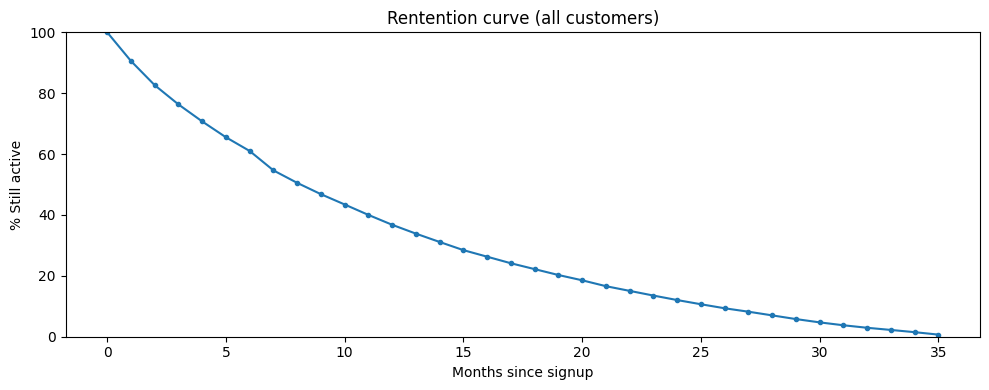

In [42]:
plt.figure(figsize=(10, 4))
plt.plot(range(max_t), [r * 100 for r in retention], marker='.')
plt.title('Rentention curve (all customers)')
plt.xlabel('Months since signup')
plt.ylabel('% Still active')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

Cohort based on channel and subscriptions

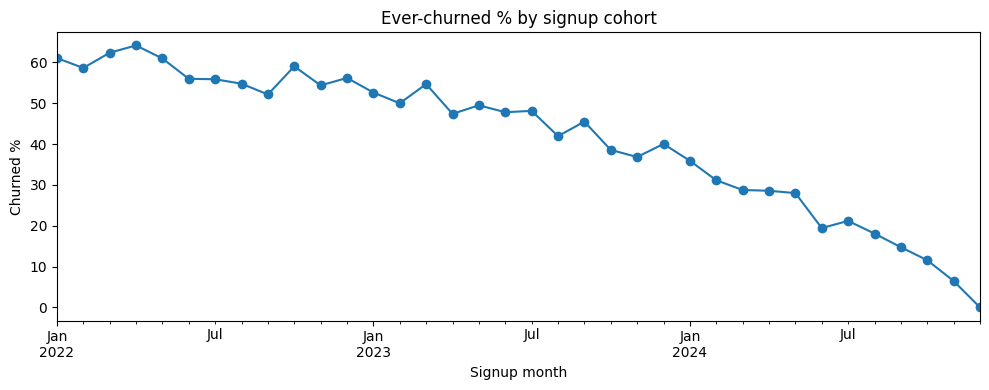

In [43]:
# Cohorts
cohort_churn = scv.groupby('signup_month')['churned'].mean() * 100

plt.figure(figsize=(10, 4))
cohort_churn.plot(marker='o')
plt.title('Ever-churned % by signup cohort')
plt.xlabel('Signup month')
plt.ylabel('Churned %')
plt.tight_layout()
plt.show()

In [44]:
df_merged.to_csv("merged_closure.csv", index=True)

In [45]:
df_merged.head()

,customer_id,signup_month,last_active,tenure_months,channel,age_band,region,first_plan,last_plan,total_revenue,max_paid,ever_paid,churned,close_month,reason_code
0,1,2022-01,2022-06,6,Comparison Site,25-34,Scotland,Classic,Classic,0,0,False,True,2022-07,Switched provider
1,2,2022-01,2024-12,36,Online,55-64,London,Silver,Platinum,595,28,True,False,NaN,NaN
2,3,2022-01,2024-12,36,Branch,25-34,South East,Platinum,Platinum,848,28,True,False,NaN,NaN
3,4,2022-01,2024-12,36,Referral,25-34,London,Silver,Silver,330,11,True,False,NaN,NaN
4,5,2022-01,2022-10,10,Comparison Site,35-44,South East,Silver,Classic,33,11,True,True,2022-11,Bereavement


In [46]:
df_merged.isna().sum()

,0
customer_id,0
signup_month,0
last_active,0
tenure_months,0
channel,0
age_band,0
region,0
first_plan,0
last_plan,0
total_revenue,0


In [47]:
df_merged_chruned = df_merged.dropna()

**LIFETIME VALUE (LTV)**

In [48]:
df.head()

,customer_id,month,acquisition_channel,region,age_band,account_tier,monthly_fee,joined_on_promo
0,1,2022-01,Comparison Site,Scotland,25-34,Classic,0,False
280,1,2022-02,Comparison Site,Scotland,25-34,Classic,0,False
840,1,2022-03,Comparison Site,Scotland,25-34,Classic,0,False
1664,1,2022-04,Comparison Site,Scotland,25-34,Classic,0,False
2750,1,2022-05,Comparison Site,Scotland,25-34,Classic,0,False


In [51]:
scv.groupby('first_plan')['total_revenue'].mean().round(2)

,total_revenue
first_plan,
Classic,26.54
Gold,226.38
Platinum,326.41
Silver,115.49


ARPU - Total money from paying customer's divided by their total active months

In [54]:
pay = scv[scv['ever_paid']]
arpu = pay['total_revenue'].sum() / pay['tenure_months'].sum()
print(f"ARPU per active month: £{arpu:.2f}")

ARPU per active month: £14.58


Monthly Churn - Look at each paying month and peek at the same customer's next month using *.shift(-1)*

In [56]:
paying = df[df['joined_on_promo'] == False].copy()

paying['next_month'] = paying.groupby('customer_id')['month'].shift(-1)   # peek at next month
paying['is_last_row'] = paying['next_month'].isna()
paying['churned_here'] = paying['is_last_row'] & (paying['month'] < final_month)
paying[['customer_id', 'month', 'next_month', 'churned_here']].head()

,customer_id,month,next_month,churned_here
0,1,2022-01,2022-02,False
280,1,2022-02,2022-03,False
840,1,2022-03,2022-04,False
1664,1,2022-04,2022-05,False
2750,1,2022-05,2022-06,False


In [60]:
monthly_churn = paying['churned_here'].mean()
print(f'Monthly churn rate: {monthly_churn:.1%}')

ltv = arpu / monthly_churn
print(f'Naive LTV estimates: £{ltv:,.0f}')

Monthly churn rate: 2.8%
Naive LTV estimates: £523


Raw Churn by channel

In [61]:
raw = (paying.groupby('acquisition_channel')['churned_here'].mean() * 100).round(2)
raw.sort_values(ascending=False)

,churned_here
acquisition_channel,
Comparison Site,5.00
Outbound,4.32
Online,3.24
Branch,1.80
Referral,1.75
Broker/IFA,1.52


Churn by channel within each plan

In [62]:
within = (paying.groupby(['account_tier', 'acquisition_channel'])['churned_here'].mean() * 100).round(2)
within.unstack()

acquisition_channel,Branch,Broker/IFA,Comparison Site,Online,Outbound,Referral
account_tier,,,,,,
Classic,4.99,4.74,7.86,6.08,6.95,4.56
Gold,1.41,1.37,2.28,2.03,2.42,1.31
Platinum,0.89,0.73,1.02,1.24,2.05,0.68
Silver,2.32,3.02,4.20,3.22,4.19,2.52


The hidden cause: plan mix

In [63]:
# One row per customer (drop_duplicates), then see each channel's split across the plans
first_rows = df.drop_duplicates('customer_id')
plan_mix = pd.crosstab(first_rows['acquisition_channel'], first_rows['account_tier'], normalize='index') * 100
plan_mix.round(1)

account_tier,Classic,Gold,Platinum,Silver
acquisition_channel,,,,
Branch,14.9,36.0,21.0,28.0
Broker/IFA,4.7,41.3,34.3,19.7
Comparison Site,45.5,12.1,2.4,40.0
Online,31.3,20.4,9.8,38.5
Outbound,35.5,18.9,5.4,40.2
Referral,13.2,34.1,19.3,33.4
